In [13]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import gc

In [14]:
files = [
    "merged_1star.csv",
    "merged_2star.csv",
    "merged_3star.csv",
    "merged_4star.csv",
    "merged_5star.csv"
]

In [15]:
scaler = StandardScaler()

for file in files:
    df = pd.read_csv(file)

    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # 🔥 remove bad rows
    df = df.dropna(subset=['Rating'])

    scaler.partial_fit(df[features])

    del df
    gc.collect()

In [17]:
X = []
y = []

for file in files:
    print("Processing:", file)

    df = pd.read_csv(file)

    # clean columns
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]
    df.columns = df.columns.str.strip()

    # 🔥 fix Sr.No issue
    if 'Sr.No.' in df.columns:
        df = df.rename(columns={'Sr.No.': 'SrNo'})

    df = df.drop(columns=['SrNo'], errors='ignore')

    # 🔥 remove NaN ratings
    df = df.dropna(subset=['Rating'])

    # 🔥 fix timestamp
    df['Timestamp'] = pd.to_numeric(df['Timestamp'], errors='coerce')

    # remove bad timestamps
    df = df.dropna(subset=['Timestamp'])

    # sort
    df = df.sort_values(by='Timestamp')

    # 🔥 detect sessions
    df['time_diff'] = df['Timestamp'].diff()
    df['session_id'] = (df['time_diff'] > 2000).cumsum()

    # drop timestamp columns
    df = df.drop(columns=['Timestamp', 'time_diff'])

    # normalize
    df[features] = scaler.transform(df[features])

    # 🔥 sequence creation per session
    for session in df['session_id'].unique():
        session_df = df[df['session_id'] == session]

        data = session_df[features].values
        labels = session_df['Rating'].values

        if len(data) < SEQ_LEN:
            continue

        for i in range(len(data) - SEQ_LEN):

            # 🔥 skip NaN labels
            if np.isnan(labels[i+SEQ_LEN]):
                continue

            X.append(data[i:i+SEQ_LEN])
            y.append(labels[i+SEQ_LEN])

    del df
    gc.collect()

Processing: merged_1star.csv
Processing: merged_2star.csv
Processing: merged_3star.csv
Processing: merged_4star.csv
Processing: merged_5star.csv


In [23]:
X = np.array(X, dtype=np.float32)
y = np.array(y)

# 🔥 remove any remaining NaNs
mask = ~np.isnan(y)

X = X[mask]
y = y[mask]

y = y.astype(np.int32)

y = y - 1   # 🔥 convert labels 1–5 → 0–4

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2348078, 30, 6)
y shape: (2348078,)


In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # 🔥 VERY IMPORTANT
)

In [25]:
model = tf.keras.Sequential([
    tf.keras.layers.LSTM(64, return_sequences=True, input_shape=(SEQ_LEN, len(features))),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.LSTM(32),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [26]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [27]:
history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 281s 9ms/step - accuracy: 0.7983 - loss: 0.4985 - val_accuracy: 0.8893 - val_loss: 0.2677
Epoch 2/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 278s 9ms/step - accuracy: 0.9014 - loss: 0.2452 - val_accuracy: 0.9225 - val_loss: 0.1872
Epoch 3/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 278s 9ms/step - accuracy: 0.9236 - loss: 0.1887 - val_accuracy: 0.9371 - val_loss: 0.1515
Epoch 4/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 279s 10ms/step - accuracy: 0.9350 - loss: 0.1595 - val_accuracy: 0.9444 - val_loss: 0.1339
Epoch 5/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 279s 9ms/step - accuracy: 0.9418 - loss: 0.1423 - val_accuracy: 0.9503 - val_loss: 0.1179
Epoch 6/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 325s 10ms/step - accuracy: 0.9467 - loss: 0.1295 - val_accuracy: 0.9549 - val_loss: 0.1066
Epoch 7/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 329s 10ms/step - accuracy: 0.9501 - loss: 0.1211 - val_accuracy: 0.9573 - val_loss: 0.0989
Epoch 8/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 313s 10ms/step 

In [28]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred))

14676/14676 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step
              precision    recall  f1-score   support

           0       0.95      0.97      0.96    114932
           1       0.97      0.98      0.97     97164
           2       0.97      0.95      0.96    141099
           3       0.94      0.94      0.94     30408
           4       0.96      0.97      0.97     86013

    accuracy                           0.96    469616
   macro avg       0.96      0.96      0.96    469616
weighted avg       0.96      0.96      0.96    469616



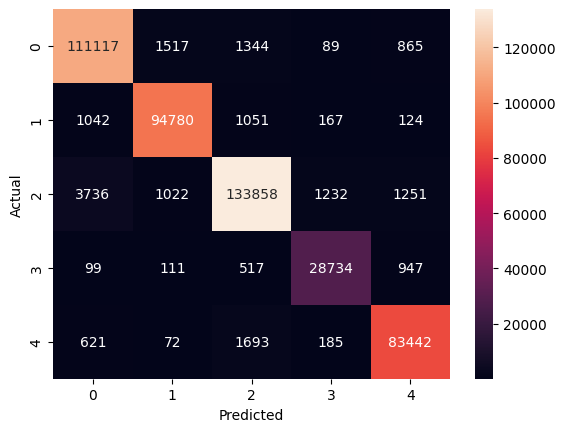

In [29]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

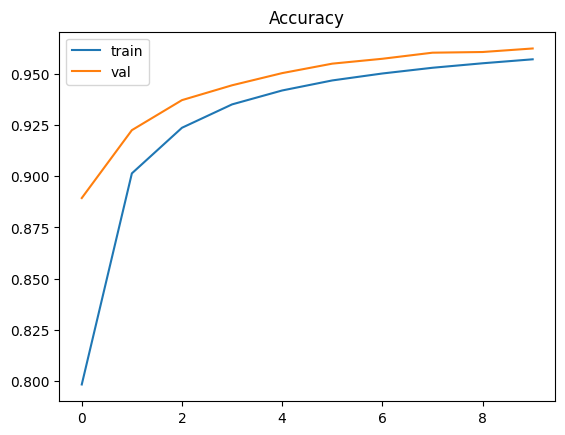

In [30]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.legend()
plt.title("Accuracy")
plt.show()

In [31]:
model.save("lstm_driving_model.keras")

In [32]:
from tensorflow.keras.models import load_model

model = load_model("lstm_driving_model.keras")

In [33]:
model.evaluate(X_test, y_test)

14676/14676 ━━━━━━━━━━━━━━━━━━━━ 73s 5ms/step - accuracy: 0.9623 - loss: 0.0873


[0.08731701970100403, 0.9623415470123291]

In [34]:
import joblib

joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

**GRU MODEL**

In [35]:
import tensorflow as tf

gru_model = tf.keras.Sequential([
    tf.keras.layers.GRU(64, return_sequences=True, input_shape=(SEQ_LEN, len(features))),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.GRU(32),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(5, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [36]:
gru_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
history_gru = gru_model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=64,
    validation_data=(X_test, y_test)
)

Epoch 1/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 290s 10ms/step - accuracy: 0.8050 - loss: 0.4942 - val_accuracy: 0.8865 - val_loss: 0.2907
Epoch 2/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 280s 10ms/step - accuracy: 0.8943 - loss: 0.2692 - val_accuracy: 0.9156 - val_loss: 0.2104
Epoch 3/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 278s 9ms/step - accuracy: 0.9119 - loss: 0.2230 - val_accuracy: 0.9230 - val_loss: 0.1903
Epoch 4/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 278s 9ms/step - accuracy: 0.9206 - loss: 0.2001 - val_accuracy: 0.9307 - val_loss: 0.1700
Epoch 5/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 275s 9ms/step - accuracy: 0.9263 - loss: 0.1858 - val_accuracy: 0.9381 - val_loss: 0.1515
Epoch 6/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 275s 9ms/step - accuracy: 0.9300 - loss: 0.1757 - val_accuracy: 0.9417 - val_loss: 0.1432
Epoch 7/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 273s 9ms/step - accuracy: 0.9328 - loss: 0.1692 - val_accuracy: 0.9441 - val_loss: 0.1357
Epoch 8/10
29351/29351 ━━━━━━━━━━━━━━━━━━━━ 274s 9ms/step - 

In [42]:
import numpy as np
from sklearn.metrics import classification_report

y_pred_gru = np.argmax(gru_model.predict(X_test), axis=1)

print(classification_report(y_test, y_pred_gru))

14676/14676 ━━━━━━━━━━━━━━━━━━━━ 41s 3ms/step
              precision    recall  f1-score   support

           0       0.94      0.95      0.94    114932
           1       0.95      0.95      0.95     97164
           2       0.95      0.92      0.94    141099
           3       0.89      0.96      0.92     30408
           4       0.95      0.96      0.95     86013

    accuracy                           0.94    469616
   macro avg       0.94      0.95      0.94    469616
weighted avg       0.94      0.94      0.94    469616



In [39]:
gru_model.save("gru_driving_model.keras")

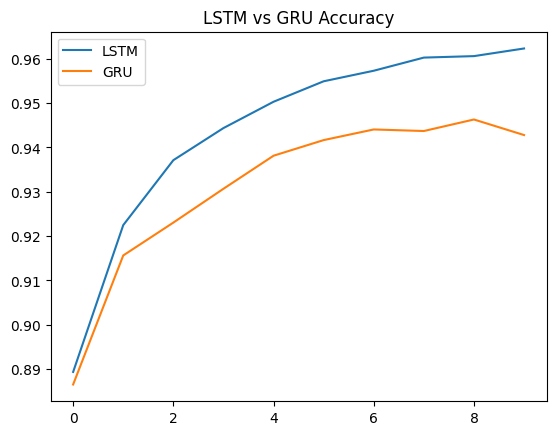

In [41]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_accuracy'], label='LSTM')
plt.plot(history_gru.history['val_accuracy'], label='GRU')

plt.legend()
plt.title("LSTM vs GRU Accuracy")
plt.show()

**PREDICTION AND TRUSTWORTHINESS EVALUATION**

In [43]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
import joblib

# load model & scaler
model = load_model("lstm_driving_model.keras")
scaler = joblib.load("scaler.pkl")

features = ['X_Acc','Y_Acc','Z_Acc','X_Gyro','Y_Gyro','Z_Gyro']
SEQ_LEN = 30

In [44]:
def prepare_sequence(df):
    df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

    # 🔥 REMOVE RATING COLUMN
    df = df.drop(columns=['Rating'], errors='ignore')

    df[features] = scaler.transform(df[features])

    data = df[features].values

    if len(data) < SEQ_LEN:
      raise ValueError("Not enough data for sequence")

    return np.expand_dims(data[-SEQ_LEN:], axis=0)

In [45]:
def predict_driver_behavior(df):
    seq = prepare_sequence(df)

    probs = model.predict(seq)[0]

    # class prediction (0–4 → 1–5)
    pred_class = np.argmax(probs) + 1

    # 🔥 Driving Score (weighted)
    driving_score = np.sum(probs * np.array([1,2,3,4,5]))

    # 🔥 Risk Score (inverse)
    risk_score = 5 - driving_score

    return {
        "Predicted Rating": pred_class,
        "Driving Score": round(driving_score, 2),
        "Risk Score": round(risk_score, 2),
        "Confidence": round(np.max(probs), 2)
    }

In [46]:
df_test = pd.read_csv("merged_3star.csv")

result = predict_driver_behavior(df_test)

print(result)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step
{'Predicted Rating': np.int64(3), 'Driving Score': np.float64(2.79), 'Risk Score': np.float64(2.21), 'Confidence': np.float32(0.79)}


In [47]:
loss, acc = model.evaluate(X_test, y_test)
print("Accuracy:", acc)

14676/14676 ━━━━━━━━━━━━━━━━━━━━ 89s 6ms/step - accuracy: 0.9623 - loss: 0.0873
Accuracy: 0.9623415470123291


14676/14676 ━━━━━━━━━━━━━━━━━━━━ 44s 3ms/step


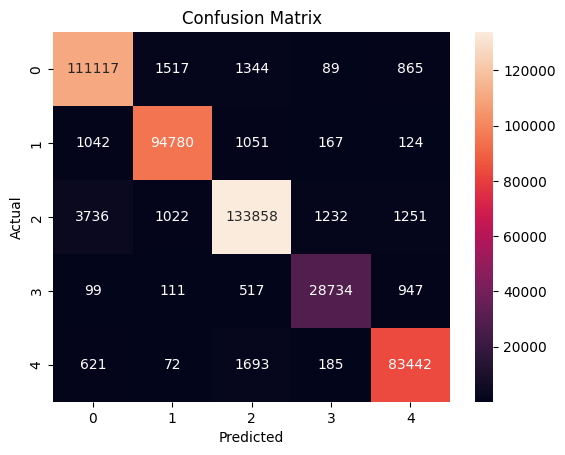

In [48]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [49]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.97      0.96    114932
           1       0.97      0.98      0.97     97164
           2       0.97      0.95      0.96    141099
           3       0.94      0.94      0.94     30408
           4       0.96      0.97      0.97     86013

    accuracy                           0.96    469616
   macro avg       0.96      0.96      0.96    469616
weighted avg       0.96      0.96      0.96    469616



In [50]:
print("Train Accuracy:", history.history['accuracy'][-1])
print("Validation Accuracy:", history.history['val_accuracy'][-1])

Train Accuracy: 0.9570537209510803
Validation Accuracy: 0.9623415470123291


In [51]:
def evaluate_trustworthiness(train_acc, val_acc):
    gap = abs(train_acc - val_acc)

    if gap < 0.03:
        return "High Trustworthiness (Good Generalization)"
    elif gap < 0.07:
        return "Moderate Trustworthiness"
    else:
        return "Low Trustworthiness (Overfitting Risk)"

print(evaluate_trustworthiness(
    history.history['accuracy'][-1],
    history.history['val_accuracy'][-1]
))

High Trustworthiness (Good Generalization)
